# 08 · GSE65391 · RNA_array · heatmap, k-means on both axes

Reads `modules.rds`, `wgcna_input.rds`, `metadata.rds`. Same matrix as notebook 07.

**Clustering.** k-means (50 random starts) applied separately to the genes (rows) and to the
patients (columns). For each axis, k is the value from 2 to 8 with the highest mean silhouette width
on Euclidean distance. If the best k is 8, the edge of the range, the silhouette may still be rising:
that is reported, not hidden.

**Tests.**
1. Gene clusters against WGCNA modules: cross-table, and the adjusted Rand index (ARI; 1 = identical
   partitions, 0 = chance).
2. Patient clusters against each clinical trait, as in notebook 07: Kruskal–Wallis or Fisher, BH q.
   **A finding** is q < 0.05.
3. Patient k-means clusters against the hierarchical groups of notebook 07: cross-table and ARI.

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize); library(cluster)})
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
m    <- readRDS(art("GSE65391", "metadata.rds"))[rownames(w$datExpr), ]
hub  <- unlist(lapply(mods$hubs, head, 10))
gene_module <- mods$colors[hub]
Z <- t(scale(w$datExpr[, hub]))
ari <- function(a, b) {
  tab <- table(a, b); c2 <- function(x) x * (x - 1) / 2
  e <- sum(c2(rowSums(tab))) * sum(c2(colSums(tab))) / c2(sum(tab))
  (sum(c2(tab)) - e) / ((sum(c2(rowSums(tab))) + sum(c2(colSums(tab)))) / 2 - e)
}
choose_k <- function(X, label) {
  set.seed(SEED)
  fits <- lapply(2:8, function(k) kmeans(X, k, nstart = 50, iter.max = 100))
  sil  <- sapply(fits, function(f) mean(silhouette(f$cluster, dist(X))[, "sil_width"]))
  print(data.frame(axis = label, k = 2:8, mean_silhouette = round(sil, 3)))
  fits[[which.max(sil)]]
}
km_genes    <- choose_k(Z, "genes")
km_patients <- choose_k(t(Z), "patients")
gene_cluster    <- factor(paste0("G", km_genes$cluster))
patient_cluster <- factor(paste0("K", km_patients$cluster))
c(k_genes = nlevels(gene_cluster), k_patients = nlevels(patient_cluster))

   axis k mean_silhouette
1 genes 2           0.225
2 genes 3           0.208
3 genes 4           0.217
4 genes 5           0.229
5 genes 6           0.244
6 genes 7           0.258
7 genes 8           0.272


      axis k mean_silhouette
1 patients 2           0.165
2 patients 3           0.117
3 patients 4           0.109
4 patients 5           0.099
5 patients 6           0.099
6 patients 7           0.093
7 patients 8           0.089


k_genes k_patients 
         8          2

**Result.** Patients: k = 2 (silhouette 0.165). Genes: k = 8, the edge of the range tried; the
silhouette was still rising, so the genes may support more clusters than 8.

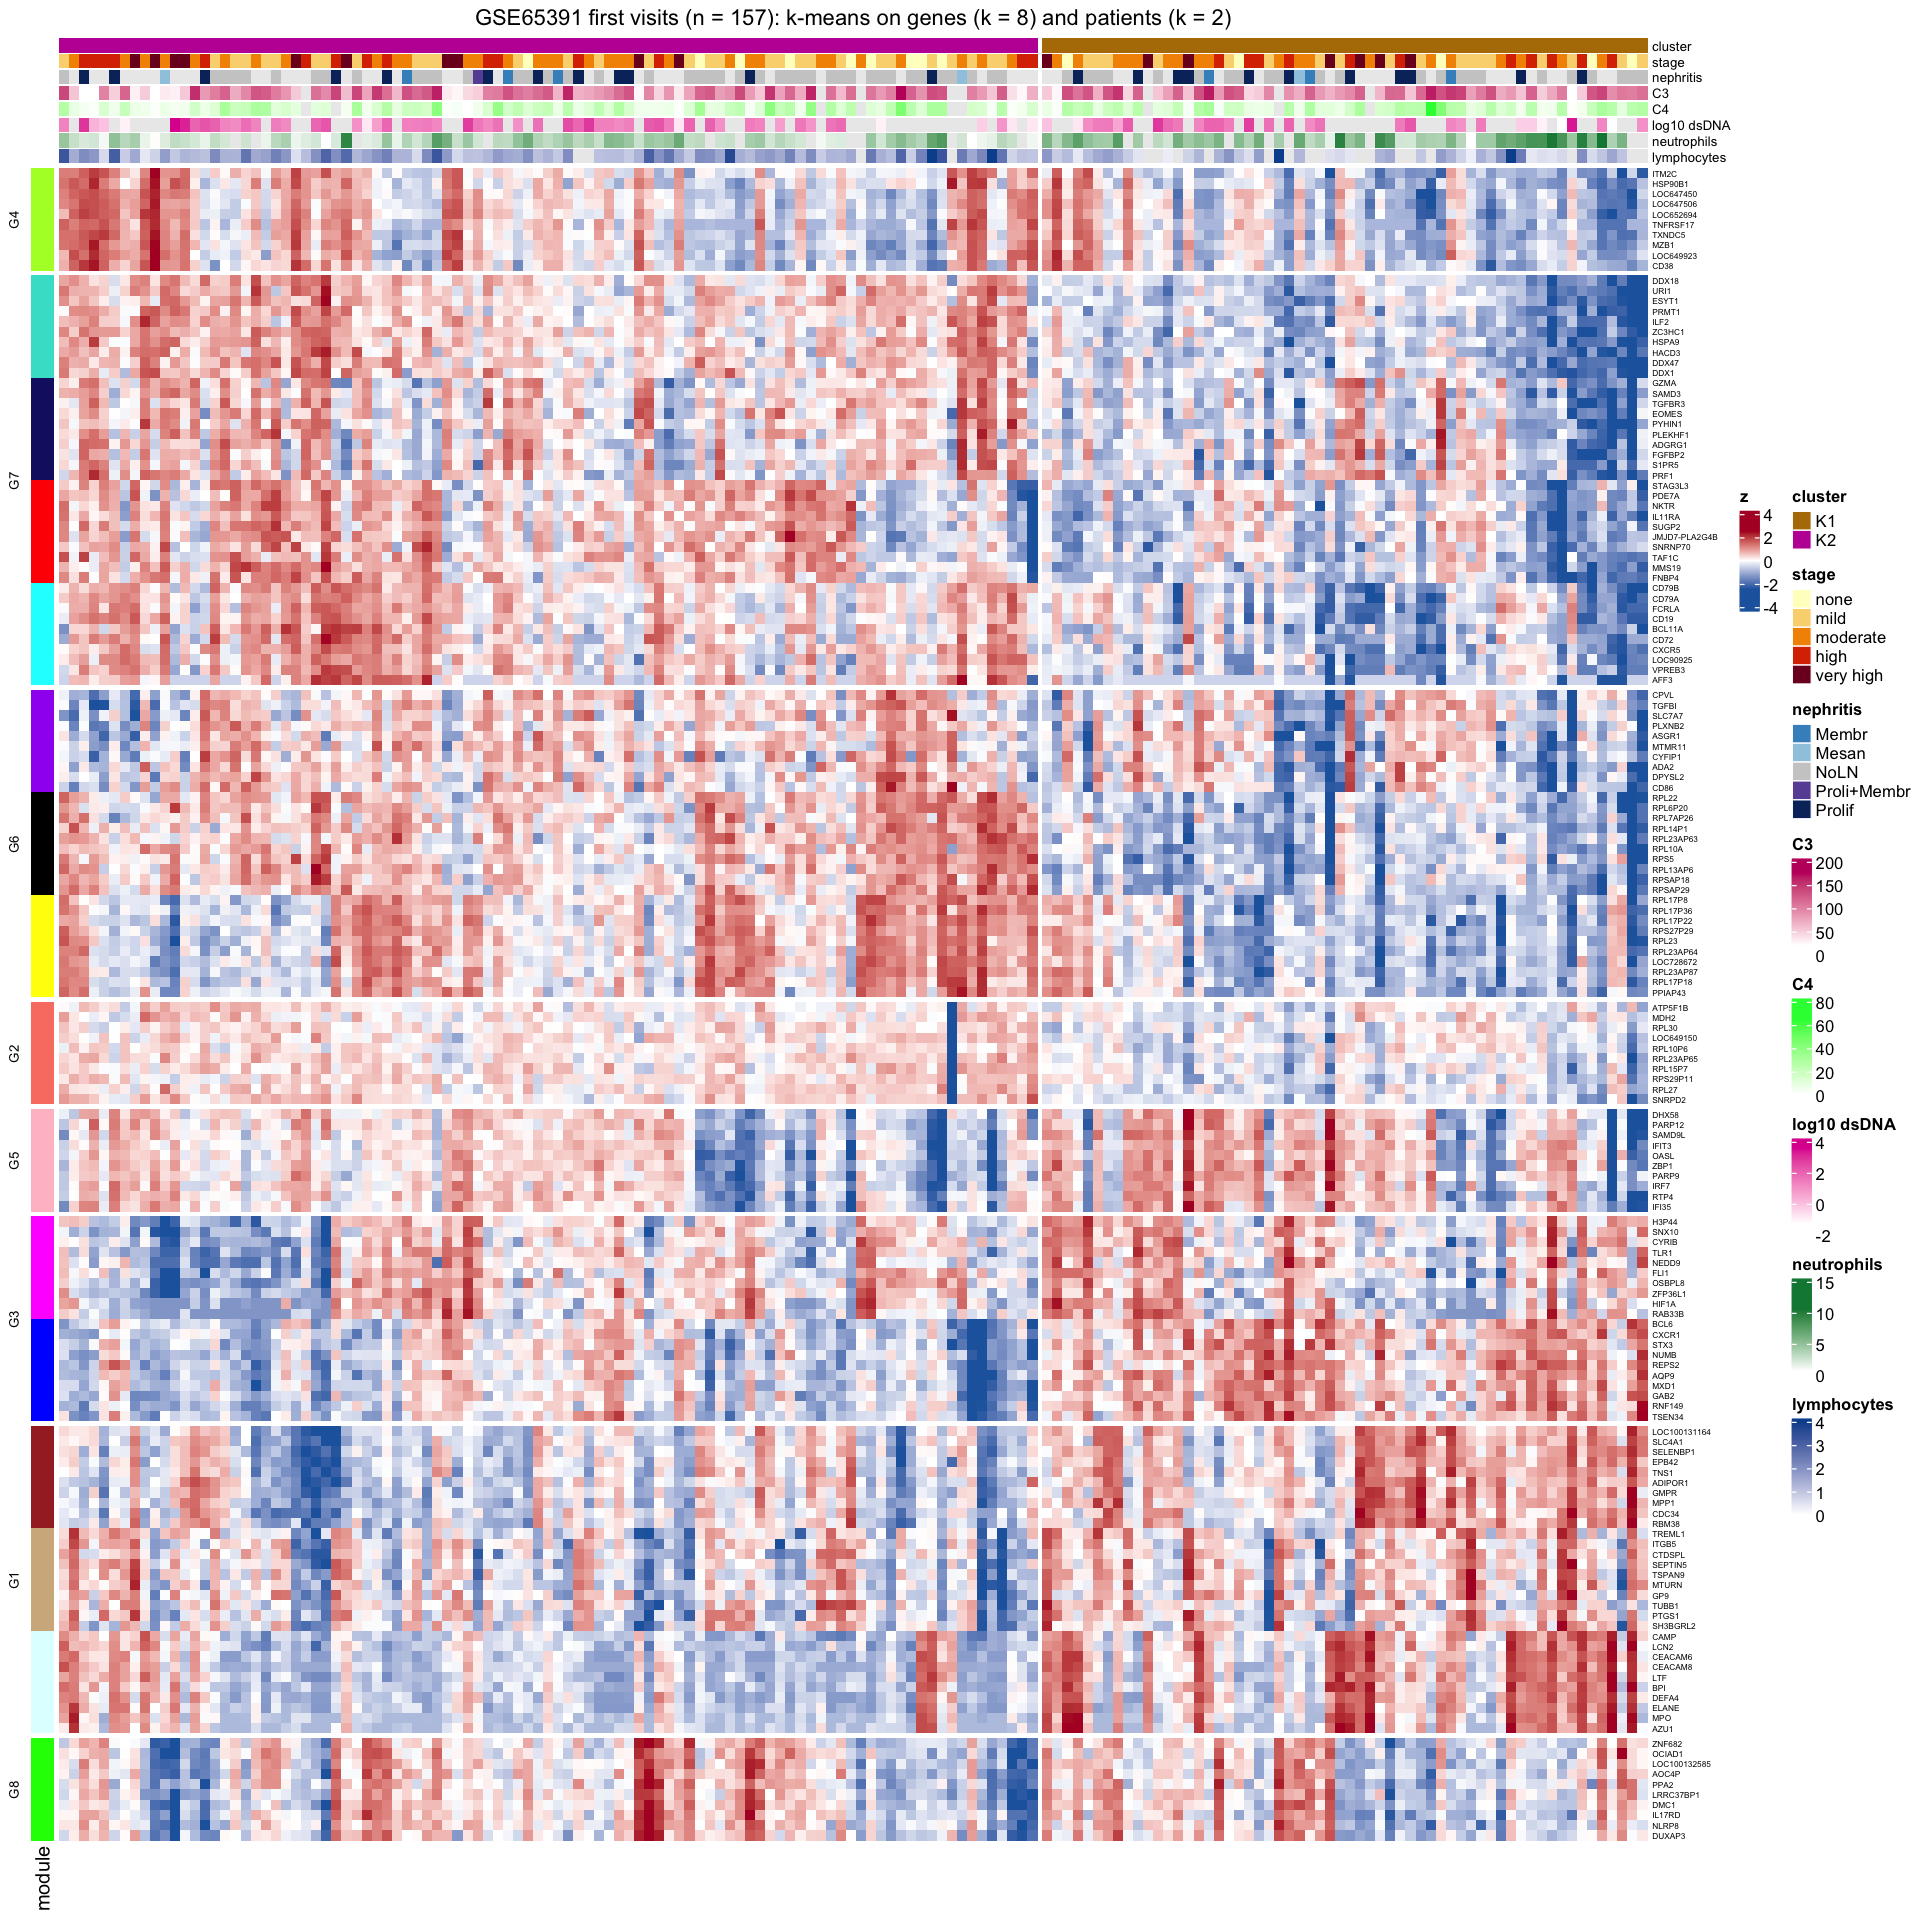

In [2]:
Zc <- pmin(pmax(Z, -2.5), 2.5)
mod_col <- setNames(unique(gene_module), unique(gene_module))
top <- HeatmapAnnotation(
  cluster = patient_cluster, stage = m$stage, nephritis = m$nephritis_class,
  C3 = m$c3, C4 = m$c4, "log10 dsDNA" = log10(m$ds_dna),
  neutrophils = m$neutrophil_count, lymphocytes = m$lymphocyte_count, na_col = "grey92",
  # colour scale for lymphocytes capped at 4 (one child has 57.5, which would flatten the scale)
  col = list(stage = setNames(hcl.colors(5, "YlOrRd", rev = TRUE), levels(m$stage)),
             nephritis = c(NoLN = "grey80", Mesan = "#9ecae1", Membr = "#4292c6", Prolif = "#08306b", "Proli+Membr" = "#6a51a3"),
             lymphocytes = colorRamp2(c(0, 4), c("white", "#08519c"))),
  annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))
options(repr.plot.width = 16, repr.plot.height = 16)
Heatmap(Zc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
        row_split = gene_cluster, column_split = patient_cluster,
        cluster_rows = TRUE, cluster_columns = TRUE, clustering_method_rows = "ward.D2",
        clustering_method_columns = "ward.D2", show_row_dend = FALSE, show_column_dend = FALSE,
        show_column_names = FALSE, row_names_gp = gpar(fontsize = 5), row_title_gp = gpar(fontsize = 8),
        left_annotation = rowAnnotation(module = gene_module, col = list(module = mod_col), show_legend = FALSE),
        top_annotation = top,
        column_title = sprintf("GSE65391 first visits (n = %d): k-means on genes (k = %d) and patients (k = %d)",
                               ncol(Z), nlevels(gene_cluster), nlevels(patient_cluster)))

**Test 1.** Gene k-means clusters against WGCNA modules.

In [3]:
table(module = gene_module, gene_cluster = gene_cluster)
c(ARI_gene_clusters_vs_modules = round(ari(gene_cluster, gene_module), 3))

              gene_cluster
module         G1 G2 G3 G4 G5 G6 G7 G8
  black         0  0  0  0  0 10  0  0
  blue          0  0 10  0  0  0  0  0
  brown        10  0  0  0  0  0  0  0
  cyan          0  0  0  0  0  0 10  0
  green         0  0  0  0  0  0  0 10
  greenyellow   0  0  0 10  0  0  0  0
  lightcyan    10  0  0  0  0  0  0  0
  magenta       0  0 10  0  0  0  0  0
  midnightblue  0  0  0  0  0  0 10  0
  pink          0  0  0  0 10  0  0  0
  purple        0  0  0  0  0 10  0  0
  red           0  0  0  0  0  0 10  0
  salmon        0 10  0  0  0  0  0  0
  tan          10  0  0  0  0  0  0  0
  turquoise     0  0  0  0  0  0 10  0
  yellow        0  0  0  0  0 10  0  0

ARI_gene_clusters_vs_modules 
                       0.482

**Result.** ARI 0.48. Every module's 10 hub genes fall in a single gene cluster; with 8 clusters for
16 modules, related modules share a cluster (for example lightcyan, tan and brown).

**Test 2.** Patient k-means clusters against each clinical trait.

In [4]:
traits <- data.frame(sledai = m$sledai, stage = as.numeric(m$stage) - 1,
  nephritis_any = ifelse(is.na(m$nephritis_class), NA, as.numeric(m$nephritis_class != "NoLN")),
  nephritis_proliferative = ifelse(is.na(m$nephritis_class), NA, as.numeric(m$nephritis_class %in% c("Prolif", "Proli+Membr"))),
  age = m$age, female = as.numeric(m$sex == "F"), c3 = m$c3, c4 = m$c4, ds_dna_log10 = log10(m$ds_dna),
  wbc = m$wbc, neutrophil_count = m$neutrophil_count, lymphocyte_count = m$lymphocyte_count, platelet_count = m$platelet_count,
  oral_steroids = m$oral_steroids, iv_steroids = m$iv_steroids, mycophenolate = m$mycophenolate,
  hydroxychloroquine = m$hydroxychloroquine, cyclophosphamide = m$cyclophosphamide)
km_tests <- do.call(rbind, lapply(names(traits), function(tr) {
  v <- traits[[tr]]; ok <- !is.na(v); binary <- all(v %in% c(0, 1, NA))
  p <- if (binary) fisher.test(table(patient_cluster[ok], v[ok]))$p.value else kruskal.test(v[ok], patient_cluster[ok])$p.value
  data.frame(trait = tr, test = if (binary) "Fisher" else "Kruskal-Wallis", n = sum(ok), p = p)
}))
km_tests$q <- p.adjust(km_tests$p, "BH"); km_tests[order(km_tests$p), ]

,trait,test,n,p,q
,<chr>,<chr>,<int>,<dbl>,<dbl>
11,neutrophil_count,Kruskal-Wallis,138,2.939851e-08,5.291732e-07
10,wbc,Kruskal-Wallis,143,3.591366e-07,3.232229e-06
12,lymphocyte_count,Kruskal-Wallis,137,1.702387e-04,1.021432e-03
15,iv_steroids,Fisher,157,8.065433e-04,3.629445e-03
14,oral_steroids,Fisher,157,8.583107e-03,3.089919e-02
18,cyclophosphamide,Fisher,156,1.210682e-02,3.632047e-02
13,platelet_count,Kruskal-Wallis,148,5.149823e-02,1.324240e-01
5,age,Kruskal-Wallis,157,1.241964e-01,2.794419e-01
8,c4,Kruskal-Wallis,148,1.951965e-01,3.903930e-01


**Result.** The two k-means patient clusters differ in neutrophil count (q = 5e-7), white cell count
(q = 3e-6), lymphocyte count (q = 0.001), IV steroids (q = 0.004), oral steroids (q = 0.03) and
cyclophosphamide (q = 0.04). SLEDAI, stage and nephritis do not reach q < 0.05.

**Test 3.** Patient k-means clusters against the hierarchical groups of notebook 07 (same k rule).

In [5]:
hc <- hclust(dist(t(Z)), method = "ward.D2")
sil <- sapply(2:8, function(k) mean(silhouette(cutree(hc, k), dist(t(Z)))[, "sil_width"]))
hc_group <- factor(paste0("H", cutree(hc, (2:8)[which.max(sil)])))
table(hclust = hc_group, kmeans = patient_cluster)
c(ARI_kmeans_vs_hclust = round(ari(hc_group, patient_cluster), 3))

      kmeans
hclust K1 K2
    H1 45  1
    H2 15 96

ARI_kmeans_vs_hclust 
               0.628

**Result.** ARI 0.63: 45 of the 46 children in hierarchical group H1 fall in k-means cluster K1.